# Predicción de Pedidos Cancelados: Del Análisis de Datos al Modelado

Para este notebook, lo que haremos sera la creación de los modelos de clasificación para predecir si un pedido sera cancelado o entregado, basandonos en el análisis exploratorio de datos realizado en el notebook anterior.

## Librerías, configuraciones y carga de datos

In [6]:
# Importación y visualización de datos 
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Agregamos la carpeta superior al camino de búsqueda de Python
sys.path.append(os.path.abspath(os.path.join('../..')))

# Transformación y preparación de datos
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Modelado y evaluación
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, confusion_matrix, roc_auc_score, average_precision_score, precision_score, recall_score, f1_score
from src.functions import evaluar_y_guardar_csv

# Se establece el número máximo de núcleos de CPU que Loky puede utilizar por motivos de rendimiento y evitar sobrecarga
os.environ['LOKY_MAX_CPU_COUNT'] = '6'

In [7]:
# Configuración de colores y estilos de las graficas
color_entregado = "#4E79A7"
color_cancelado = "#E15759"
mis_colores_multi = ["#4E79A7", "#E15759", "#76B7B2", "#59A14F", "#EDC948", "#B07AA1", "#FF9DA7", "#9C755F"]

sns.set_palette(sns.color_palette(mis_colores_multi))

order_status_palette = {'Delivered': color_entregado, 'Cancelled': color_cancelado}

In [8]:
df = pd.read_parquet('../../Data/Amazon_cleaned.parquet')
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Bangalore,KA,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Indore,MP,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,Whitehorse,YT,Canada,SELL01411


## Creación de columnas previas al modelado

In [9]:
df_model = df[~df["OrderStatus"].isin(['Pending', 'Returned', 'Shipped'])].copy()
df_model["target"] = np.where(df_model["OrderStatus"] == 'Cancelled', 1, 0)

# Creación de la columna 'Month'
df_model['Month'] = pd.to_datetime(df_model['OrderDate']).dt.month

# Creación de la columna 'Day'
df_model['Day'] = pd.to_datetime(df_model['OrderDate']).dt.dayofweek

## Transformación y preparación de datos

In [10]:
X = df_model[['Country', 'PaymentMethod', 'Category', 'Day', 'Quantity', 'UnitPrice']]
y = df_model['target']


X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=42, stratify=y_train)

In [11]:
bins = pd.qcut(X_train['UnitPrice'], q=3, retbins=True, duplicates='drop')[1]

X_train['Product_Value'] = pd.cut(X_train['UnitPrice'], bins=bins, labels=[1,2,3], include_lowest=True)
X_val['Product_Value']  = pd.cut(X_val['UnitPrice'],  bins=bins, labels=[1,2,3], include_lowest=True)
X_test['Product_Value']  = pd.cut(X_test['UnitPrice'],  bins=bins, labels=[1,2,3], include_lowest=True)
X_train['Product_Value'] = X_train['Product_Value'].astype('int64')
X_val['Product_Value']  = X_val['Product_Value'].astype('int64')
X_test['Product_Value']  = X_test['Product_Value'].astype('int64')

In [12]:
cat_cols = ['Country', 'PaymentMethod', 'Category']
num_cols = ['Product_Value', 'Day', 'Quantity', 'UnitPrice']

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

Para la etapa de transformación, hemos optado por el método **OneHotEncoder**. A diferencia de la codificación anterior, esta técnica garantiza que no se asigne un orden jerárquico artificial a las categorías, tratando a todos los valores con la misma importancia. No obstante, dado que una expansión excesiva de columnas podría aumentar el riesgo de sobreajuste (overfitting) y elevar considerablemente los tiempos de entrenamiento, hemos decidido utilizar únicamente las variables que obtuvieron las mejores puntuaciones de relevancia. Este enfoque inicial nos permite mantener un modelo equilibrado, dejando abierta la posibilidad de ajustar la selección de variables en caso de que los resultados no alcancen el rendimiento esperado.

Con los datos ya transformados, el siguiente paso consistirá en realizar la separación de las variables predictoras y la variable objetivo (target). Posteriormente, dividiremos el conjunto en datos de entrenamiento y de prueba; este proceso es fundamental para evaluar la capacidad del modelo de generalizar sus predicciones ante información nueva y asegurar que el sistema de detección de cancelaciones sea realmente efectivo y confiable antes de su implementación.

Tras realizar la partición de los datos en conjuntos de entrenamiento y prueba, se confirmó el desbalance que habíamos identificado previamente. La proporción de pedidos cancelados es significativamente menor en comparación con los pedidos entregados, una situación común en este tipo de análisis que podría causar que el modelo aprenda a predecir con mayor facilidad la clase mayoritaria e ignore los casos de cancelación.

Para solucionar este inconveniente, aplicaremos una técnica de sobremuestreo denominada **SMOTE**. El objetivo de este método es generar datos sintéticos de la clase minoritaria hasta lograr que ambos tipos de pedidos estén al mismo nivel; de esta manera, garantizamos que el modelo reciba la misma cantidad de información para ambas categorías, permitiéndole aprender de forma equitativa a identificar tanto las entregas exitosas como las cancelaciones

## Balanceo de clases

Tras aplicar la técnica de sobremuestreo, las clases en el conjunto de entrenamiento presentan ahora una distribución equitativa. Es fundamental destacar que este proceso se realizó exclusivamente sobre los datos de entrenamiento para evitar la filtración de datos (data leakage); si balanceáramos también el conjunto de prueba, los resultados de evaluación serían artificialmente positivos, ya que el modelo no estaría aprendiendo a generalizar, sino simplemente a reconocer patrones de datos sintéticos que ya conoce. No obstante, somos conscientes de que generar una gran cantidad de registros para la clase de cancelaciones puede introducir ruido en el modelo, por lo que, si las métricas de precisión o la curva ROC resultan bajas, consideraremos implementar métodos alternativos de balanceo.

Por consiguiente, iniciaremos la fase de modelado comparando tres de los algoritmos de clasificación más robustos: Random Forest, XGBoost y CatBoost. Al implementar ambas arquitecturas, podremos evaluar cuál de ellas se adapta mejor a la complejidad de nuestras variables y cuál ofrece un rendimiento superior en la detección de pedidos cancelados. Este análisis comparativo será clave para identificar la herramienta más precisa y confiable antes de proceder con el ajuste final de hiperparámetros.

## Creación y evaluación de los modelos

### Modelo Random Forest Classifier

Para la construcción del modelo **Random Forest**, iniciamos con un proceso de ajuste de hiperparámetros mediante `param_grid` para identificar la configuración que mejor se adaptaba a nuestros datos. Una vez obtenidos los parámetros óptimos, definimos un nuevo diccionario con estos valores específicos; esta estrategia permite que el notebook se ejecute de manera ágil en futuras sesiones sin necesidad de repetir la búsqueda intensiva, optimizando así los tiempos de procesamiento sin sacrificar la precisión del modelo.

Despues, procederemos a evaluar el desempeño del modelo utilizando el `classification_report` y una función personalizada que se encargará de registrar los valores de **AUC-ROC** y **F1-score** directamente en un archivo CSV ubicado en la carpeta "Data". Este método de almacenamiento permitirá que cada nuevo modelo agregue sus resultados de forma automática al archivo existente, creando así un registro centralizado y persistente que facilitará la comparación final de todos los experimentos realizados. Asimismo, analizaremos la matriz de confusión y la gráfica de importancia de variables; esta última nos servirá como guía para identificar las características que menos aportan al modelo, con el fin de eliminarlas en una etapa posterior y observar si esta simplificación mejora los resultados del entrenamiento.

In [13]:
# Puede tardarse un poco en ejecutarse
rf_pipe = Pipeline(steps=[
    ('prep', preprocess),
    ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

param_dist = {
    'model__n_estimators': randint(200, 800),
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': randint(2, 10),
    'model__min_samples_leaf': randint(1, 6),
    'model__max_features': ['sqrt', 'log2', None],
}

rand_search = RandomizedSearchCV(rf_pipe, param_distributions=param_dist, n_iter=25,cv=5,
                                 scoring='f1', random_state=42, n_jobs=-1)
rand_search.fit(X_train, y_train)

print(f"Mejores parámetros: {rand_search.best_params_}")
best_rf = rand_search.best_estimator_

Mejores parámetros: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 3, 'model__n_estimators': 587}


--- REPORTE DE MÉTRICAS FINAL ---
ROC-AUC: 0.49758229708807683
PR-AUC: 0.03961696729659066
Precision (pos): 0.03766105054509415
Recall (pos): 0.1254125412541254
F1 (pos): 0.057926829268292686


<Figure size 800x600 with 0 Axes>

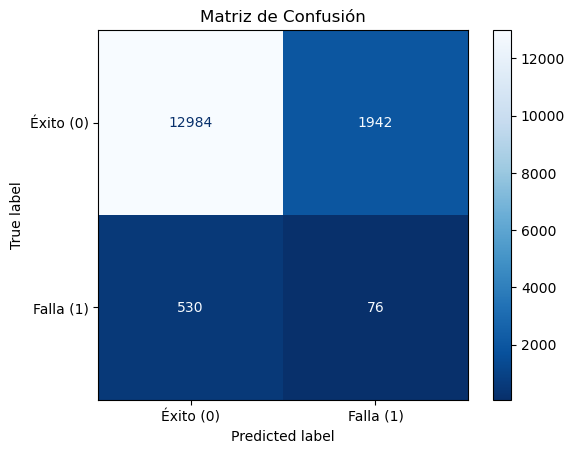

In [15]:
print("--- REPORTE DE MÉTRICAS FINAL ---")
y_probs = best_rf.predict_proba(X_test)[:, 1]
y_pred = (y_probs >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_probs))
print("PR-AUC:", average_precision_score(y_test, y_probs))
print("Precision (pos):", precision_score(y_test, y_pred))
print("Recall (pos):", recall_score(y_test, y_pred))
print("F1 (pos):", f1_score(y_test, y_pred))
# evaluar_y_guardar_csv(best_rf, X_test, y_test, 'RandomForest v6.0', nombre_archivo='metricas_modelos_clasificacion_1.csv')

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Éxito (0)', 'Falla (1)'])
disp.plot(cmap='Blues_r', values_format='d')
plt.title('Matriz de Confusión')
plt.show()

# importances_clf = pd.DataFrame({
#     'Variable': X.columns,
#     'Importance': best_rf.feature_importances_
# }).sort_values(by="Importance", ascending=False)

# sns.barplot( data=importances_clf.head(20), x='Importance', y='Variable', hue = 'Variable', palette='Blues_r')
# plt.title('Random Forest - Clasificación')
# plt.show()

### Modelo XGBoost

Para el modelo de **XGBoost**, seguiremos una estrategia distinta para el manejo de los datos, enfocándonos en la configuración de parámetros que permitan al algoritmo gestionar el desbalance de clases de forma interna. Al ajustar el parámetro de balanceo (como `scale_pos_weight`), el modelo otorga mayor importancia a los pedidos cancelados sin necesidad de recurrir a los datos generados por SMOTE; esto nos permite trabajar con la distribución original de la información, buscando un aprendizaje más natural y reduciendo el riesgo de sobreajuste por datos sintéticos.

En cuanto a la evaluación, mantendremos la misma metodología aplicada en el modelo de Random Forest para asegurar una comparativa justa. Utilizaremos el reporte de clasificación y nuestra función personalizada para almacenar el **AUC-ROC** y el **F1-score** en el archivo csv que guarda todos resultados finales. Asimismo, analizaremos la matriz de confusión y la importancia de las variables para determinar si existen características que no aportan valor significativo; de ser así, procederemos a eliminarlas en una siguiente prueba para verificar si esto optimiza el rendimiento general del modelo.

In [16]:
# 1. Calculamos el factor de escala para el desbalance
counts = y_train.value_counts()
scale_weight = counts[0] / counts[1]

# 2. Creamos el modelo XGBoost y asignamos parametros
xgb_pipe = Pipeline(steps=[
    ('prep', preprocess),
    ('model', xgb.XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight=scale_weight,
        random_state=42
    ))
])

param_dist_xgb = {
    'model__n_estimators': randint(200, 800),
    'model__max_depth': randint(3, 10),
    'model__learning_rate': uniform(0.01, 0.2),
    'model__subsample': uniform(0.6, 0.4),
    'model__colsample_bytree': uniform(0.6, 0.4)
}

xgb_search = RandomizedSearchCV(xgb_pipe, param_distributions=param_dist_xgb, n_iter=25,
    cv=5, scoring='f1', random_state=42, n_jobs=-1
)

# 3. Entrenamiento
xgb_search.fit(X_train, y_train)

print("Mejores parámetros XGBoost:", xgb_search.best_params_)
best_xgb = xgb_search.best_estimator_
# evaluar_y_guardar_csv(xgb_clf, X_test, y_test, 'XGBoost v6.0', nombre_archivo='metricas_modelos_clasificacion_1.csv')

Mejores parámetros XGBoost: {'model__colsample_bytree': 0.8446612641953124, 'model__learning_rate': 0.011413261043943482, 'model__max_depth': 3, 'model__n_estimators': 760, 'model__subsample': 0.8099098641033556}


Mejor umbral: 0.05
Mejor F1 en validación: 0.074986443566504
--- REPORTE DE MÉTRICAS FINAL ---
ROC-AUC: 0.49030851430312533
PR-AUC: 0.03953399595802436
Precision (pos): 0.0390162245686325
Recall (pos): 1.0
F1 (pos): 0.07510224315280704


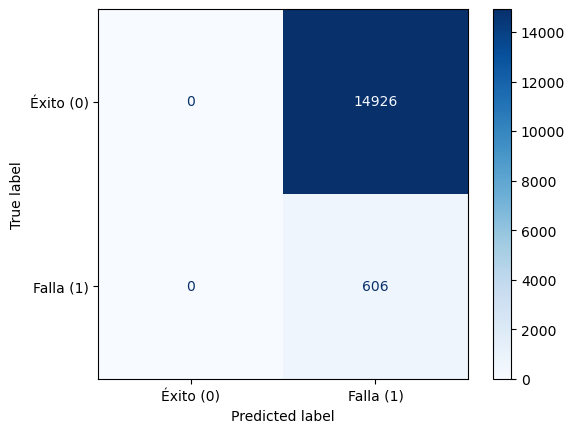

In [17]:
y_val_probs = best_xgb.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.05, 0.95, 19)
f1_scores = [f1_score(y_val, (y_val_probs >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1_scores)]

print("Mejor umbral:", best_t)
print("Mejor F1 en validación:", max(f1_scores))

# Evaluación final en test
y_test_probs = best_xgb.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_probs >= best_t).astype(int)

print("--- REPORTE DE MÉTRICAS FINAL ---")
print("ROC-AUC:", roc_auc_score(y_test, y_test_probs))
print("PR-AUC:", average_precision_score(y_test, y_test_probs))
print("Precision (pos):", precision_score(y_test, y_test_pred))
print("Recall (pos):", recall_score(y_test, y_test_pred))
print("F1 (pos):", f1_score(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Éxito (0)', 'Falla (1)'])
disp.plot(cmap='Blues')
plt.show()

### Modelo CatBoost

Para el desarrollo del modelo **CatBoost**, hemos optado por una estrategia similar a la de XGBoost, aprovechando la capacidad nativa del algoritmo para gestionar el desbalance de clases de forma interna. Una de las mayores ventajas de este modelo es su facultad para procesar variables categóricas sin necesidad de transformaciones manuales previas; esto evita aumentar innecesariamente el número de columnas y previene que se asigne una importancia arbitraria a ciertos datos, como ocurría con otros métodos de codificación. Al configurar los parámetros que priorizan la clase minoritaria, trabajamos con la distribución original de los datos, lo que permite un aprendizaje más genuino y reduce el riesgo de sobreajuste.

En cuanto a la evaluación, seguiremos empleando el `classification_report` y nuestra función personalizada para capturar las métricas de **AUC-ROC** y **F1-score**. Estos resultados se enviarán automáticamente al archivo **CSV** en la carpeta **'data'**, integrándose con los registros de los modelos anteriores. Una vez finalizado este proceso, contaremos con una base de datos completa que nos permitirá comparar formalmente el rendimiento de Random Forest, XGBoost y CatBoost, identificando finalmente cuál de estas arquitecturas es la más eficaz para predecir las cancelaciones en el dataset.

In [18]:
categorical_features = ['Country', 'PaymentMethod', 'Category']

# 1. Configurar el modelo
cat_model = CatBoostClassifier(
    auto_class_weights='Balanced',
    loss_function='Logloss',
    verbose=0,
    allow_writing_files=False,
    random_state=42
)

param_dist_cat = {
    'iterations': randint(300, 800),
    'depth': randint(4, 10),
    'learning_rate': uniform(0.01, 0.2),
    'l2_leaf_reg': uniform(1, 5)
}

cat_search = RandomizedSearchCV(cat_model, param_distributions=param_dist_cat, n_iter=25,
    cv=5, scoring='f1', random_state=42, n_jobs=-1)

# 2. Entrenar el modelo
cat_search.fit(X_train, y_train, cat_features=categorical_features)

print("Mejores parámetros CatBoost:", cat_search.best_params_)
best_cat = cat_search.best_estimator_

# evaluar_y_guardar_csv(cat_model, X_test_cat, y_test_cat, 'CatBoost v6.0',  nombre_archivo='metricas_modelos_clasificacion_1.csv')

Mejores parámetros CatBoost: {'depth': 4, 'iterations': 759, 'l2_leaf_reg': 4.0582658024414044, 'learning_rate': 0.011413261043943482}


Mejor umbral: 0.35
Mejor F1 en validación: 0.07500387416705408
--- REPORTE DE MÉTRICAS FINAL ---
ROC-AUC: 0.5064004976807476
PR-AUC: 0.04155688422404552
Precision (pos): 0.039043876038915015
Recall (pos): 1.0
F1 (pos): 0.07515346933713649


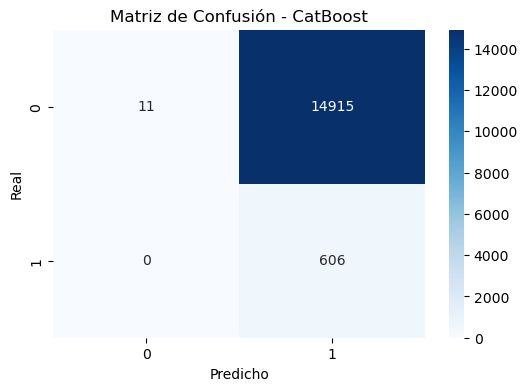

In [19]:
y_val_probs = best_cat.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.05, 0.95, 19)
f1_scores = [f1_score(y_val, (y_val_probs >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1_scores)]

print("Mejor umbral:", best_t)
print("Mejor F1 en validación:", max(f1_scores))

# Evaluación final en test
y_test_probs = best_cat.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_probs >= best_t).astype(int)

print("--- REPORTE DE MÉTRICAS FINAL ---")
print("ROC-AUC:", roc_auc_score(y_test, y_test_probs))
print("PR-AUC:", average_precision_score(y_test, y_test_probs))
print("Precision (pos):", precision_score(y_test, y_test_pred))
print("Recall (pos):", recall_score(y_test, y_test_pred))
print("F1 (pos):", f1_score(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - CatBoost')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()